# Instructions for the Coding Practice

---

Welcome to your coding practice! In this exercise, you will work with a dataset related to the **Rick and Morty** TV show. This coding practice is designed to test your data manipulation and analysis skills. Please follow the instructions below carefully:

1. **Understand the Dataset**: The dataset used in this coding practice is based on the Rick and Morty TV show. Take time to explore and understand its structure and contents before beginning the tasks.

2. **Read Each Question Thoroughly**: Each task is designed to assess specific data handling skills. Be sure to fully understand what each question is asking before you start working on your solution.

3. **Write Your Code in the Provided Cells**: For every question, a code cell is provided where you should enter your solution. Do not alter any other parts of the coding practice template.

4. **Execute Your Code**: After writing your code in each cell, run it to check whether the output matches the requirements. Make sure the results are correct and consistent with the instructions.

5. **Complete All Questions**: Be sure to answer every question included in the coding practice. Each one evaluates different concepts and techniques.

6. **Review Your Work**: Before final submission, carefully review your answers. Ensure that all code cells have been executed, outputs are accurate, and there are no errors in your notebook.

7. **Download Your Notebook**: Once you’ve finished and reviewed your work, download the notebook file (`.ipynb`). In Google Colab, this can be done via `File` > `Download` > `Download .ipynb`.

8. **Submit Your Coding Practice**: Upload the downloaded file to the appropriate platform designated for submissions.

9. **Verify Submission**: Double-check that the correct file was uploaded and that it opens properly. If something goes wrong, re-download and re-submit as necessary.

---

**Good luck with your Coding Practice!**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

character_data_url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/characters_dataset.csv"
episodes_data_url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/episodes_dataset.csv"
locations_data_url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/locations_dataset.csv"

characters = pd.read_csv(character_data_url,index_col=0)
episodes = pd.read_csv(episodes_data_url,index_col=0)
locations = pd.read_csv(locations_data_url,index_col=0)

1. **Which gender category has the highest count?**

In [2]:
# Write your code here to visualize the data

gender_counts = characters['gender'].value_counts().rename_axis('gender').rename('count')
print(gender_counts)


gender
Male       15
Female      4
unknown     1
Name: count, dtype: int64


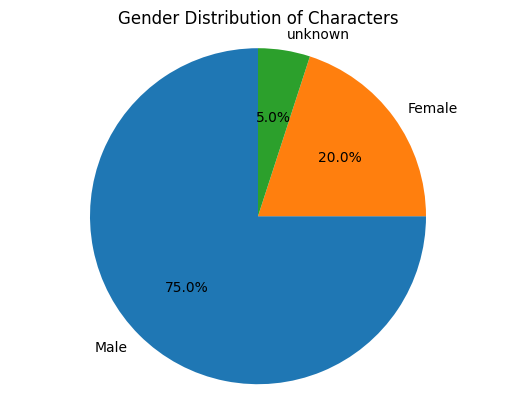

In [3]:
# Write your code here to visualize the data

labels = gender_counts.index
sizes = gender_counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Gender Distribution of Characters")
plt.axis('equal')  # Equal aspect ratio to ensure pie is round
plt.show()

2. **How many characters have each life status?**

In [4]:
# Write your code here to visualize the data

status_counts = characters['status'].value_counts()
status_counts.index.name = 'status'
status_counts.name = 'count'
print(status_counts)

status
Alive      8
unknown    6
Dead       6
Name: count, dtype: int64


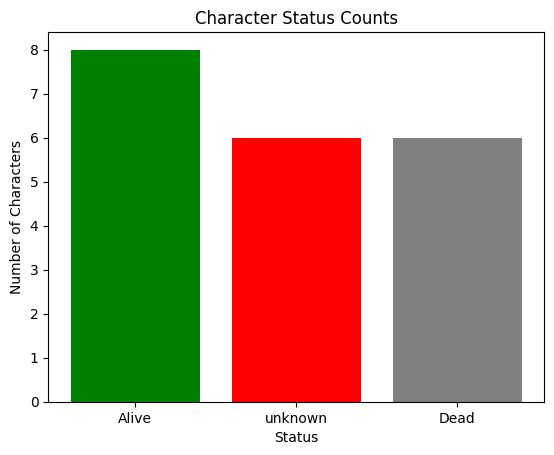

In [5]:
# Write your code here to visualize the data

plt.bar(status_counts.index, status_counts.values, color=['green','red','gray'])
plt.xlabel('Status')
plt.ylabel('Number of Characters')
plt.title('Character Status Counts')
plt.show()

3. **How many characters belong to each species?**


In [6]:
# Write your code here to visualize the data

species_counts = characters['species'].value_counts()
species_counts.index.name = 'species'
species_counts.name = 'count'
print(species_counts)

species
Human    15
Alien     5
Name: count, dtype: int64


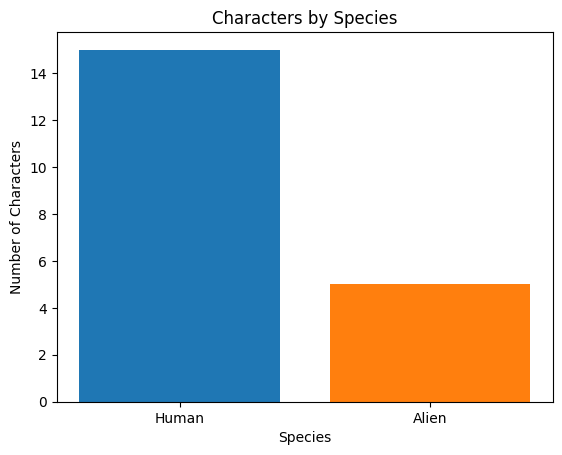

In [7]:
# Write your code here to visualize the data

plt.bar(species_counts.index, species_counts.values, color=['#1f77b4','#ff7f0e'])
plt.xlabel('Species')
plt.ylabel('Number of Characters')
plt.title('Characters by Species')
plt.show()


4. **Which characters appear in the most episodes?**

In [8]:
# Write your code here to visualize the data

# Count episodes by counting the number of URLs (each contains “http”)
characters['episode_count'] = characters['episode'].str.count(r'https?://')

# Select top 5 characters by episode_count
top5 = (
    characters
    .nlargest(5, 'episode_count')[['name', 'episode_count']]
)

print(top5)


           name  episode_count
0  Rick Sanchez             51
1   Morty Smith             51
2  Summer Smith             42
3    Beth Smith             42
4   Jerry Smith             39


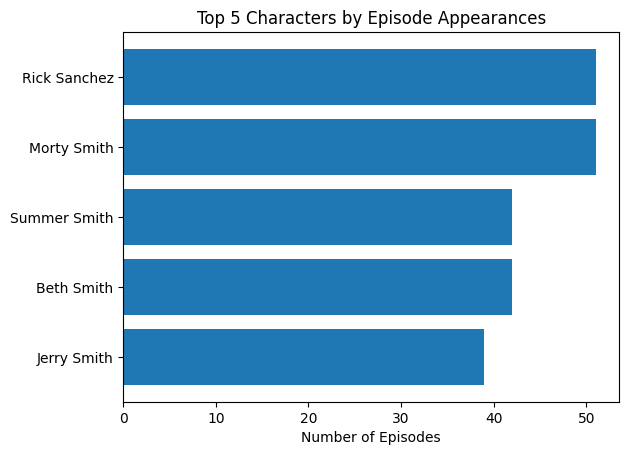

In [9]:
# Write your code here to visualize the data

# Horizontal bar chart for top 5 characters
plt.barh(top5['name'], top5['episode_count'])
plt.xlabel('Number of Episodes')
plt.title('Top 5 Characters by Episode Appearances')
plt.gca().invert_yaxis()  # largest bar at top
plt.show()

5. **How many episodes are in each season?**

In [10]:
# Write your code here to visualize the data

# Extract season number from episode code (e.g., "S01E05" -> 1)
season_counts = episodes['episode'].str.extract(r'S(\d+)')[0].astype(int).value_counts().sort_index()
season_counts.index.name = 'season'
season_counts.name = 'count'
print(season_counts)

season
1    11
2     9
Name: count, dtype: int64


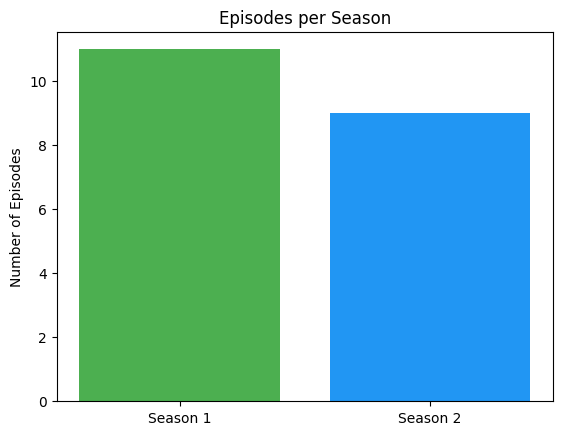

In [11]:
# Write your code here to visualize the data

seasons = ['Season '+str(s) for s in season_counts.index]
plt.bar(seasons, season_counts.values, color=['#4caf50','#2196f3'])
plt.ylabel('Number of Episodes')
plt.title('Episodes per Season')
plt.show()

6. **Which episodes have the largest cast of characters?**

In [12]:
# Write your code here to visualize the data

# Calculate number of characters appearing in each episode
episodes['num_chars'] = episodes['characters'].apply(lambda x: len(ast.literal_eval(x)))
top_episodes = episodes[['episode','name','num_chars']].sort_values('num_chars', ascending=False).head(5)
print(top_episodes[['episode','name','num_chars']])

   episode                                     name  num_chars
9   S01E10     Close Rick-counters of the Rick Kind         60
7   S01E08                            Rixty Minutes         57
18  S02E08  Interdimensional Cable 2: Tempting Fate         40
12  S02E02                           Mortynight Run         36
15  S02E05                             Get Schwifty         31


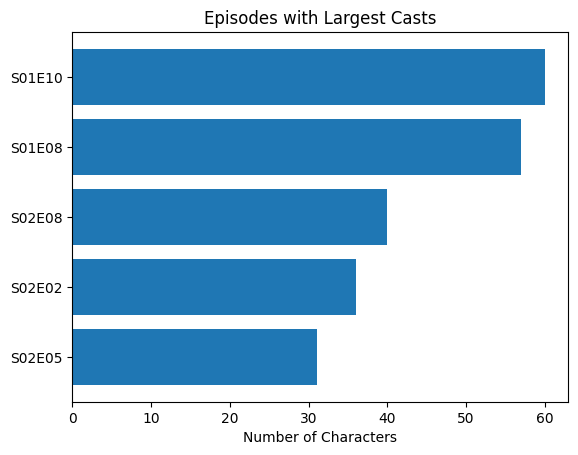

In [13]:
# Write your code here to visualize the data

plt.barh(top_episodes['episode'], top_episodes['num_chars'])
plt.xlabel('Number of Characters')
plt.title('Episodes with Largest Casts')
plt.gca().invert_yaxis()  # largest at top
plt.show()

7. **How does the number of characters per episode change over the first two seasons?**

In [14]:
# Write your code here to visualize the data

episodes['num_chars'] = episodes['characters'].apply(lambda x: len(ast.literal_eval(x)))

episode_counts = episodes.sort_values('id')[['episode','num_chars']]
print(episode_counts.to_string(index=False))

episode  num_chars
 S01E01         19
 S01E02         19
 S01E03         24
 S01E04         13
 S01E05         20
 S01E06         24
 S01E07         14
 S01E08         57
 S01E09         17
 S01E10         60
 S01E11         30
 S02E01         13
 S02E02         36
 S02E03         14
 S02E04         24
 S02E05         31
 S02E06         19
 S02E07         26
 S02E08         40
 S02E09         10


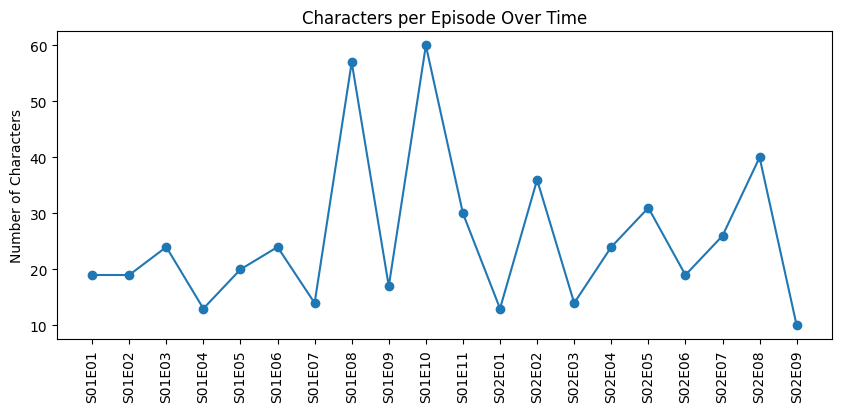

In [15]:
# Write your code here to visualize the data

plt.figure(figsize=(10,4))
eps_sorted = episodes.sort_values('id')
plt.plot(eps_sorted['num_chars'], marker='o')
plt.xticks(ticks=range(len(eps_sorted)), labels=eps_sorted['episode'], rotation=90)
plt.ylabel('Number of Characters')
plt.title('Characters per Episode Over Time')
plt.show()

8. **How does the distribution of episode cast sizes differ between Season 1 and Season 2?**

In [16]:
# Write your code here to visualize the data

# Extract season number if not already done
episodes['season'] = episodes['episode'].str.extract(r'S(\d+)')[0].astype(int)

# Count number of characters per episode
episodes['num_chars'] = episodes['characters'].apply(lambda x: len(ast.literal_eval(x)))

# Compute stats per season
season_stats = episodes.groupby('season')['num_chars'].agg(['count', 'mean', 'median', 'min', 'max'])

print(season_stats)


        count       mean  median  min  max
season                                    
1          11  27.000000    20.0   13   60
2           9  23.666667    24.0   10   40


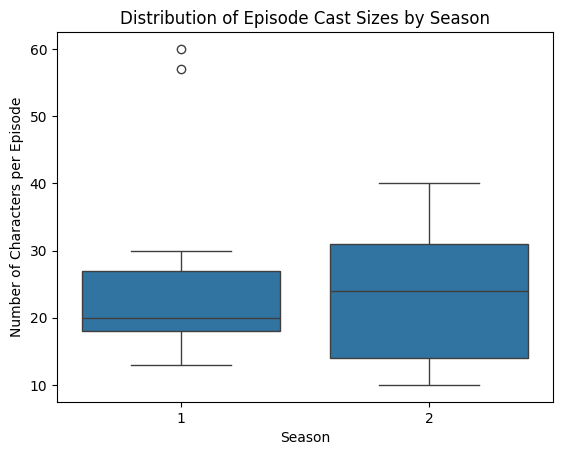

In [17]:
# Write your code here to visualize the data

sns.boxplot(x='season', y='num_chars', data=episodes)
plt.xlabel('Season')
plt.ylabel('Number of Characters per Episode')
plt.title('Distribution of Episode Cast Sizes by Season')
plt.show()

# END